# ISEL - Processamento de Imagem e Visão(PIV)
## Semestre de Inverno 2025/26
# <br>
###  <center> Trabalho Prático 1 </center>
###  <center> Trabalho nº 2.A – Contagem de Veículos em Imagens de Vídeo </center>
# </br>



Trabalho realizado por:


| Aluno | Número |
|-------|--------|
| **Ruben Zhang** | A51388 |
| **Rodrigo Neves** | A51452 |


<b> Turma 51D - Docente: Pedro Jorge </b>

<b>Objetivos:</b>


<b>Descrição:</b>


In [109]:
#Imports necessários ao longo do trabalho
import numpy as np
import matplotlib.pyplot as plt
import cv2


In [110]:

def AbrirVideo(caminho, janela=False): #REFATORAR DPS SE NECESSARIO
    cap = cv2.VideoCapture(caminho)

    if not cap.isOpened():
        print(f"Error: Não conseguiu abrir o video em: {caminho}")
        return [], None, 0

    print("Video aberto com sucesso!")

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = round(cap.get(cv2.CAP_PROP_FPS))
    if fps <= 0 or fps is None or fps != fps:  # fps != fps para apanhar NaN
        fps = 30

    frame_interval_ms = int(1000 / fps)
    print(f"Total frames: {frame_count}, FPS: {fps}")

    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            print("Fi do video alcançado ou erro na leitura do frame.")
            break
        
        frames.append(frame)
        if (janela):
            cv2.imshow("Video Frame", frame)
            tecla = cv2.waitKey(frame_interval_ms) & 0xFF
            if tecla == ord('q') or tecla == 27:
                break

    cap.release()
    cv2.destroyAllWindows()
    return frames, fps, frame_count



In [111]:
def DefinirVistaImagem(pts, imagem):
    mascara = np.zeros(imagem.shape[:2], dtype=np.uint8)
    cv2.fillPoly(mascara, [np.int32(pts)], 255)
    img_vista = cv2.bitwise_and(imagem, imagem, mask=mascara)
    return img_vista


def DesenharPontosVista(frame, pts_src, mostrar=False):
    frameCopia= frame.copy()

    # Desenhar os pontos
    for p in pts_src:
        cv2.circle(frameCopia, tuple(map(int, p)), 4, (0, 0, 255), -1)  # Ponto em vermelho

    # Desenhar o polígono com os pontos
    quad = np.array([pts_src[0], pts_src[1], pts_src[2], pts_src[3]], dtype=np.int32)

    cv2.polylines(frameCopia, [quad], True, color=(255, 0, 0), thickness=2)
    
    if mostrar:
        plt.imshow(cv2.cvtColor(frameCopia, cv2.COLOR_BGR2RGB))
        plt.title("imagem com pontos da vista")
        plt.grid()
        plt.show()
    return frameCopia



def CorrigirPerspetiva(frame, pts_src, altura_dst, largura_dst, mostrar=False):
    # 1. Verificar se o frame é válido
    if frame is None:
        print("Frame inválido!")
        return None
    
    altura_dst, largura_dst = frame.shape[:2]
    
    # 2. Criar os pontos destino, na mesma ordem que pts_src
    pts_dst = np.float32([
        [0, 0],                         # topo-esquerdo
        [largura_dst - 1, 0],           # topo-direito
        [0, altura_dst - 1],            # fundo-esquerdo
        [largura_dst - 1, altura_dst - 1]  # fundo-direito
    ])

    # 3. Calcular a matriz de homografia
    matriz = cv2.getPerspectiveTransform(pts_src, pts_dst)

    # 4. Aplicar a transformação de perspetiva para o tamanho desejado
    img_corrigida = cv2.warpPerspective(frame, matriz, (largura_dst, altura_dst))
    # Mostrar o resultado

    if mostrar:
        plt.imshow(cv2.cvtColor(img_corrigida, cv2.COLOR_BGR2RGB))
        plt.title("imagem corrigida da perspetiva")
        plt.grid()
        plt.show()

    return img_corrigida


In [112]:

def EstimacaoImageFundo(caminho, n_amostras=24, guardar=False, mostrar=False):
    cap = cv2.VideoCapture(caminho)
    if not cap.isOpened():
        print("Erro: não conseguiu abrir o vídeo!")
        return None
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    # Selecionar frames espaçados
    indices = np.linspace(0, total - 1, n_amostras).astype(int)
    frames = []
    for i in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, i)
        ret, frame = cap.read()
        if ret:
            frames.append(frame)
    cap.release()
    if len(frames) == 0:
        print("Erro: sem frames suficientes para calcular o fundo.")
        return None
    fundo = np.median(frames, axis=0).astype(np.uint8)

    if guardar:
        plt.imsave("fundo_estimado.jpg", fundo)
    if mostrar:
        plt.imshow(cv2.cvtColor(fundo, cv2.COLOR_BGR2RGB))
        plt.title("imagem do fundo estimado")
        plt.axis("off")
        plt.show()
    return fundo


def DetetarPixeisAtivos(frame, frame_fundo_estimado, limiar, mostrar=False):
    frameG = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    fundoG = cv2.cvtColor(frame_fundo_estimado, cv2.COLOR_BGR2GRAY)

    diff = cv2.absdiff(frameG, fundoG)

    # clahe = cv2.createCLAHE(clipLimit=5.0, tileGridSize=(8,8))
    # diff = clahe.apply(diff)

    diff = cv2.medianBlur(diff, 15)
    diff = cv2.GaussianBlur(diff, (5, 5), 0)

    _, bin_img = cv2.threshold(diff, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    if mostrar:
        plt.figure(figsize=(12, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(frameG, cmap='gray')
        plt.title("Frame Original em Cizento")
        plt.grid(True)

        plt.subplot(1, 3, 2)
        plt.imshow(diff, cmap='gray')
        plt.title("Diferença entre cada frame e o fundo estimado")
        plt.grid(True)

        plt.subplot(1, 3, 3)
        plt.imshow(bin_img, cmap='gray')
        plt.title("Diferença em Binária")
        plt.grid(True)
        plt.show()

    # detetar, em cada frame, quais os píxeis que mudaram em relação ao fundo — 
    # ou seja, os píxeis que representam objetos em movimento (carros).    
    return bin_img


def Morfologicos(bin_img):
    k_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    img = cv2.morphologyEx(bin_img, cv2.MORPH_OPEN, k_small)

    k_close = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (9, 9))
    img = cv2.morphologyEx(img, cv2.MORPH_CLOSE, k_close)
    # Dilata ligeiro para criar contornos sólidos
    k_med = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    img = cv2.dilate(img, k_med, iterations=1)
    img = cv2.dilate(img, k_small, iterations=1)

    # # Erosão para separar carros próximos
    # img = cv2.erode(img, k_med, iterations=1)

    return img


def DetecaoRegioesAtivas(img_bin, img_original):
    img = img_bin.copy()
    frame_out = img_original.copy()

    contornos, _ = cv2.findContours(img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    veiculos = []

    for c in contornos:
        area = cv2.contourArea(c)
        # Ajusta estes valores conforme o tamanho dos carros no teu vídeo
        if 400 < area < 3000:  # Alargado o range
            x, y, w, h = cv2.boundingRect(c)
            aspect_ratio = w / float(h)

            # Filtrar por aspect ratio (carros costumam ser mais largos que altos)
            if 0.5 < aspect_ratio < 4.0:
                veiculos.append([x, y, w, h])
                cv2.rectangle(frame_out, (x, y), (x + w, y + h), (0, 255, 0), 2)

    return veiculos


def DesenharVeiculos(frame, veiculos_ativos):
    frameCopy = frame.copy()

    for v in veiculos_ativos:
        x, y, w, h, ID = v

        cv2.rectangle(frameCopy, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), 2)
        cv2.putText(frameCopy, f"ID {ID}", (int(x), int(y) - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    return frameCopy


In [113]:
def CorrespondenciaImagens(Boxes, veiculos, IDatual, limiar_dist=60, max_frames_ausente=5):
    """
    Garante que cada Box corresponde a NO MÁXIMO um ID
    e cada ID corresponde a NO MÁXIMO um Box
    """

    veiculo_ids = []

    # Incrementar contador de ausência para todos
    for id_v in veiculos:
        veiculos[id_v]['ausente'] += 1

    # Calcular centros dos boxes atuais
    centros_boxes = []
    for rect in Boxes:
        x, y, w, h = rect
        cx = (x + x + w) // 2
        cy = (y + y + h) // 2
        centros_boxes.append((cx, cy, rect))

    # IDs já usados neste frame
    ids_usados = set()
    boxes_usados = set()

    # FASE 1: Matching greedy por menor distância
    matches = []  # [(dist, idx_box, id_veiculo)]

    for idx_box, (cx, cy, rect) in enumerate(centros_boxes):
        for id_exist, dados in veiculos.items():
            pcx, pcy = dados['centro']
            dist = np.hypot(cx - pcx, cy - pcy)

            if dist < limiar_dist:
                matches.append((dist, idx_box, id_exist, rect, cx, cy))

    # Ordenar por distância (menor primeiro)
    matches.sort(key=lambda m: m[0])

    # Atribuir matches garantindo unicidade
    for dist, idx_box, id_exist, rect, cx, cy in matches:
        # Se este box e este ID ainda não foram usados
        if idx_box not in boxes_usados and id_exist not in ids_usados:
            x, y, w, h = rect

            # Atualizar veículo existente
            veiculos[id_exist]['centro'] = (cx, cy)
            veiculos[id_exist]['ausente'] = 0

            veiculo_ids.append([x, y, w, h, id_exist])

            ids_usados.add(id_exist)
            boxes_usados.add(idx_box)

    # FASE 2: Criar novos IDs para boxes não matchados
    for idx_box, (cx, cy, rect) in enumerate(centros_boxes):
        if idx_box not in boxes_usados:
            x, y, w, h = rect

            # Novo veículo
            veiculos[IDatual] = {'centro': (cx, cy), 'ausente': 0}
            veiculo_ids.append([x, y, w, h, IDatual])
            print(f"Novo veículo: ID {IDatual} em ({cx}, {cy})")
            IDatual += 1

    # FASE 3: Remover IDs ausentes há muito tempo
    ids_a_remover = [id_v for id_v, dados in veiculos.items()
                     if dados['ausente'] > max_frames_ausente]

    for id_v in ids_a_remover:
        del veiculos[id_v]
        print(f"Veículo ID {id_v} removido (ausente)")

    return veiculo_ids, veiculos, IDatual

In [114]:


def DesenharLegendaContornos(contorno, img, label, velo = 1, color=(0, 0, 0)):
    
    cv2.drawContours(img, [contorno], -1, color, 2) #Desenha os contornos na imagem original
    
    M = cv2.moments(contorno) #Obtem os momentos do contorno para calcular o centro
    cX = int(M["m10"]/M["m00"]) if M["m00"] != 0 else 0 #Calcula o centroide 
    cY = int(M["m01"]/M["m00"]) if M["m00"] != 0 else 0
    # Desenhar classificação
    cv2.putText(img, label, (cX - 20, cY), cv2.FONT_HERSHEY_SIMPLEX, 0.1 , color, 2)
    # Desenhar ratio na linha abaixo
    cv2.putText(img, f"{velo:.0f} km/h", (cX - 40, cY + 20), cv2.FONT_HERSHEY_SIMPLEX, 0.1, color, 2)
    
#Contornos hull antes e depois
def ContornosHull(img_original, hulls, contornos):
    
    img_contornos = img_original.copy()
    img_hulls = img_original.copy()

    cv2.drawContours(img_contornos, contornos, -1, (0, 0, 0), 2)
    cv2.drawContours(img_hulls, hulls, -1, (0, 0, 255), 2)
    # Mostrar as duas imagens lado a lado
    plt.figure(figsize=(12, 5))
    plt.subplot(1,2,1)
    plt.imshow(cv2.cvtColor(img_contornos, cv2.COLOR_BGR2RGB))
    plt.title("Contornos Originais")
    plt.axis("off")
    plt.subplot(1,2,2)
    plt.imshow(cv2.cvtColor(img_hulls, cv2.COLOR_BGR2RGB))
    plt.title("Contornos com Convex Hull")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

def Histograma(img): #Calcula os histogramas dos três canais
    if img is None:
        print("Imagem inválida!")
        return
    
    canais = ['Blue', 'Green', 'Red']
    cores = ['b', 'g', 'r']

    plt.figure(figsize=(15, 4))

    for i, (canal, cor) in enumerate(zip(canais, cores)):
        plt.subplot(1, 3, i + 1)
        
        # Calcular histograma do canal i
        hist = cv2.calcHist([img], [i], None, [256], [0, 256])

        plt.plot(hist, color=cor)
        plt.title(f'Histograma - Canal {canal}')
        plt.xlabel('Intensidade')
        plt.ylabel('Frequência')
        plt.xlim([0, 256])
        plt.grid(True, alpha=0.5)

    plt.tight_layout()
    plt.show()



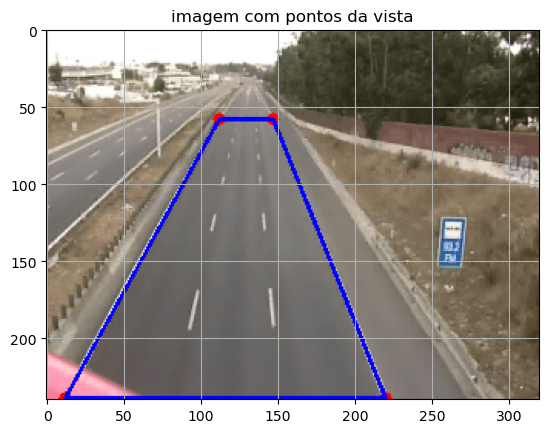

Novo veículo: ID 0 em (110, 209)
Novo veículo: ID 1 em (52, 199)
Novo veículo: ID 2 em (181, 182)
Novo veículo: ID 3 em (59, 225)
Veículo ID 1 removido (ausente)
Veículo ID 2 removido (ausente)
Veículo ID 0 removido (ausente)
Novo veículo: ID 4 em (145, 228)
Veículo ID 3 removido (ausente)
Novo veículo: ID 5 em (182, 229)
Veículo ID 4 removido (ausente)
Veículo ID 5 removido (ausente)
Novo veículo: ID 6 em (201, 230)
Novo veículo: ID 7 em (111, 222)
Veículo ID 6 removido (ausente)
Novo veículo: ID 8 em (46, 221)
Veículo ID 7 removido (ausente)
Novo veículo: ID 9 em (123, 230)
Veículo ID 8 removido (ausente)
Novo veículo: ID 10 em (112, 233)
Veículo ID 9 removido (ausente)
Novo veículo: ID 11 em (51, 214)


In [115]:
#::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::::
#-------------MAIN----------------------------------------------------------------------------


Ficheiro = "AutoEstrada.wm"
cap = cv2.VideoCapture(Ficheiro)

fps = round(cap.get(cv2.CAP_PROP_FPS))
intervalo_fps = int(1000 / fps)

ret, frame = cap.read()
altura, largura = frame.shape[:2]
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter("resultado11.mp4", fourcc, fps, (largura, altura))


# topo-esquerdo 
# topo-direito

# fundo-esquerdo 
# fundo-direito 
pts_src = np.float32([ [112, 58], 
                        [147, 58], 
                        [220, 239],
                        [12, 239] 
                        ])
#[125, 38], [140, 42], [24, 217], [220, 240] 


fundo = EstimacaoImageFundo(Ficheiro)

# fundo_corrigido = CorrigirPerspetiva(fundo, pts_src, 800, 600)
zona_detecao= DefinirVistaImagem(pts_src, fundo)


veiculos_ativos = {}  # dicionário ID -> centroide
IDatual = 0

DesenharPontosVista(fundo, pts_src, mostrar= True)


while True:
    ret, frame = cap.read()
    if not ret or frame is None:
        break

    frame_detecao= DefinirVistaImagem(pts_src, frame)
        
    # frame_corrigido = CorrigirPerspetiva(frame, pts_src, 800, 600)
    bin_img = DetetarPixeisAtivos(frame_detecao, zona_detecao, 0, mostrar=False)
    bin_clean = Morfologicos(bin_img)
    # bin_mask = DefinirVistaImagem(pts_src, bin_clean)
    # bin_masked = cv2.bitwise_and(bin_clean, bin_clean, mask=bin_mask)

    Boxes = DetecaoRegioesAtivas(bin_clean, frame)

    # Atualizar correspondências e obter o novo estado
    atualizado_veiculo, veiculos_ativos, IDatual = CorrespondenciaImagens(Boxes, veiculos_ativos, IDatual)

    frameVideo = DesenharVeiculos(frame, atualizado_veiculo)
    writer.write(frameVideo)

    cv2.namedWindow("Contagem de Veiculos", cv2.WINDOW_NORMAL)
    cv2.resizeWindow("Contagem de Veiculos", 1080, 720)
    cv2.imshow("Contagem de Veiculos", frameVideo)

    cv2.imshow("Binária", bin_img)
    cv2.imshow("Binária Op", bin_clean)
    cv2.imshow("Frame Detecção", frame_detecao)


    key = cv2.waitKey(30) & 0xFF
    if key == ord('q') or key == 27:
        break

cap.release()
writer.release()
cv2.destroyAllWindows()



#EXTRA : METER SORT TRACKER


In [116]:
def definir_linhas(altura):
    """
    Define as posições Y das linhas de entrada e saída.

    Args:
        altura: Altura do frame em pixels

    Returns:
        tuple: (linha_entrada, linha_saida) em pixels
    """
    linha_entrada = int(altura * 0.70)  # Linha inferior (cruzada primeiro)
    linha_saida = int(altura * 0.55)    # Linha superior (cruzada depois)
    return linha_entrada, linha_saida

def desenhar_linhas(frame, y_entrada, y_saida):
    """
    Desenha as linhas de detecção no frame.

    Args:
        frame: Frame de vídeo
        y_entrada: Posição Y da linha de entrada
        y_saida: Posição Y da linha de saída

    Returns:
        Frame com as linhas desenhadas
    """
    altura, largura = frame.shape[:2]

    # Linha de entrada (vermelha)
    cv2.line(frame, (0, y_entrada), (largura, y_entrada), (0, 0, 255), 2)
    cv2.putText(frame, "ENTRADA", (10, y_entrada + 25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

    # Linha de saída (azul)
    cv2.line(frame, (0, y_saida), (largura, y_saida), (255, 0, 0), 2)
    cv2.putText(frame, "SAIDA", (10, y_saida - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)

    return frame

In [117]:
ficheiro = "AutoEstrada.wm"
cap = cv2.VideoCapture(ficheiro)

ret, frame = cap.read()
if not ret:
    print("Erro ao abrir vídeo!")
    exit()

altura, largura = frame.shape[:2]
fps = round(cap.get(cv2.CAP_PROP_FPS))

# Definir linhas fixas
linha1_y, linha2_y = definir_linhas(altura)

print(f"Linha ENTRADA Y = {linha1_y}")
print(f"Linha SAIDA Y = {linha2_y}")
print(f"Distância entre linhas (px): {abs(linha2_y - linha1_y)}")

# Criar writer IDENTICO ao teu formato original
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter("resultado_com_linhas.mp4", fourcc, fps, (largura, altura))

# Loop do vídeo
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame = desenhar_linhas(frame, linha1_y, linha2_y)
    writer.write(frame)

    cv2.imshow("Linhas no Vídeo", frame)
    if cv2.waitKey(20) & 0xFF == ord('q'):
        break

cap.release()
writer.release()
cv2.destroyAllWindows()

print("\n✅ Vídeo processado com sucesso!")
print("📁 Guardado como: resultado_com_linhas.mp4 (mp4v)")


Linha ENTRADA Y = 168
Linha SAIDA Y = 132
Distância entre linhas (px): 36

✅ Vídeo processado com sucesso!
📁 Guardado como: resultado_com_linhas.mp4 (mp4v)


In [118]:
# ============================================================================
# PARTE 1: DETECÇÃO DE CRUZAMENTO COM INTERPOLAÇÃO
# ============================================================================

def verificar_cruzamento_linha_preciso(cy_anterior, cy_atual, linha_y, tolerancia=5):
    """
    Verifica se um veículo cruzou uma linha E calcula a fração sub-frame.

    Esta função usa interpolação linear para estimar QUANDO (entre frames)
    o veículo cruzou exatamente a linha, aumentando a precisão temporal.

    Args:
        cy_anterior: Posição Y anterior do centro do veículo
        cy_atual: Posição Y atual do centro do veículo
        linha_y: Posição Y da linha a verificar
        tolerancia: Margem de tolerância em pixels

    Returns:
        tuple: (cruzou: bool, fracao_frame: float)
               fracao_frame é um valor entre 0 e 1 que indica quando
               no intervalo entre frames o cruzamento ocorreu

    Exemplo:
        Se cy_anterior=140, cy_atual=120, linha_y=130:
        - cruzou = True
        - fracao = (140-130)/(140-120) = 0.5
        - Significa que cruzou a meio do intervalo entre frames
    """
    # Verifica se houve cruzamento (movimento de cima para baixo em Y)
    if cy_anterior > linha_y + tolerancia and cy_atual <= linha_y + tolerancia:
        # Calcular fração interpolada do frame onde ocorreu o cruzamento
        # fracao = 0.0 significa início do intervalo (frame anterior)
        # fracao = 1.0 significa fim do intervalo (frame atual)

        distancia_total = cy_anterior - cy_atual
        distancia_ate_linha = cy_anterior - linha_y

        if distancia_total > 0:
            fracao = distancia_ate_linha / distancia_total
        else:
            fracao = 0.5  # Fallback caso não haja movimento

        return True, fracao

    return False, 0.0


def calcular_velocidade(tempo_segundos, distancia_metros):
    """
    Calcula a velocidade em km/h a partir do tempo de percurso.

    Args:
        tempo_segundos: Tempo de percurso em segundos (pode ter decimais)
        distancia_metros: Distância real entre as linhas em metros

    Returns:
        float: Velocidade em km/h
    """
    if tempo_segundos <= 0:
        return 0.0

    velocidade_ms = distancia_metros / tempo_segundos
    velocidade_kmh = velocidade_ms * 3.6
    return velocidade_kmh

In [119]:
# ============================================================================
# PARTE 2: PROCESSAMENTO DE VEÍCULOS COM PRECISÃO SUB-FRAME
# ============================================================================

def atualizar_tempos_veiculos(veiculos_ativos, linha_entrada_y, linha_saida_y,
                               frame_number, fps, distancia_metros=None):
    """
    Atualiza os tempos de cruzamento com PRECISÃO SUB-FRAME.

    Em vez de contar apenas frames inteiros, calcula
    a fração exata dentro do frame onde o cruzamento ocorreu,
    resultando em medições de tempo muito mais precisas.

    Args:
        veiculos_ativos: Dicionário com informações dos veículos rastreados
        linha_entrada_y: Posição Y da linha de entrada
        linha_saida_y: Posição Y da linha de saída
        frame_number: Número do frame atual
        fps: Taxa de frames por segundo
        distancia_metros: Distância real entre linhas (opcional)

    Returns:
        dict: Dicionário com variações de tempo dos veículos que completaram
    """
    variacoes_tempo = {}

    for id_v, dados in veiculos_ativos.items():
        cx, cy = dados['centro']
        cy_anterior = dados.get('cy_anterior', cy)

        # Detecção de cruzamento da linha de ENTRADA (com interpolação)
        if dados.get('tempo_entrada') is None:
            cruzou, fracao = verificar_cruzamento_linha_preciso(
                cy_anterior, cy, linha_entrada_y
            )

            if cruzou:
                # Tempo preciso = frame_atual - 1 + fração
                # (subtraímos 1 porque a fração é relativa ao frame anterior)
                tempo_preciso = (frame_number - 1) + fracao
                dados['tempo_entrada'] = tempo_preciso

                print(f"[ENTRADA] ID {id_v} | Frame {frame_number-1}.{int(fracao*100):02d} | Y={cy}")

        # Detecção de cruzamento da linha de SAÍDA (com interpolação)
        if dados.get('tempo_saida') is None:
            cruzou, fracao = verificar_cruzamento_linha_preciso(
                cy_anterior, cy, linha_saida_y
            )

            if cruzou:
                tempo_preciso = (frame_number - 1) + fracao
                dados['tempo_saida'] = tempo_preciso

                print(f"[SAIDA]   ID {id_v} | Frame {frame_number-1}.{int(fracao*100):02d} | Y={cy}")

                t_entrada = dados.get('tempo_entrada')
                t_saida = dados.get('tempo_saida')

                # Cálculo do tempo de percurso COM PRECISÃO
                if t_entrada is not None and t_saida is not None:
                    # Agora temos valores com decimais!
                    variacao_frames = t_saida - t_entrada
                    tempo_s = variacao_frames / fps

                    variacoes_tempo[id_v] = variacao_frames
                    dados['variacao_frames'] = variacao_frames
                    dados['tempo_segundos'] = tempo_s

                    print(f"Tempo: {variacao_frames:.3f} frames ({tempo_s:.4f}s)")

                    # Cálculo da velocidade (se distância fornecida)
                    if distancia_metros:
                        velocidade = calcular_velocidade(tempo_s, distancia_metros)
                        dados['velocidade_kmh'] = velocidade
                        print(f"          Velocidade: {velocidade:.2f} km/h")

                    print()

        dados['cy_anterior'] = cy

    return variacoes_tempo

In [120]:
# ============================================================================
# PARTE 3: VISUALIZAÇÃO DOS RESULTADOS
# ============================================================================

def desenhar_veiculos_com_velocidade(frame, veiculos_ativos):
    """
    Desenha os veículos rastreados com suas informações.

    Args:
        frame: Frame de vídeo
        veiculos_ativos: Dicionário com informações dos veículos

    Returns:
        Frame com os veículos desenhados
    """
    frame_copy = frame.copy()

    for id_v, dados in veiculos_ativos.items():
        if 'ultimo_box' in dados:
            x, y, w, h = dados['ultimo_box']

            # Bounding box
            cv2.rectangle(frame_copy, (int(x), int(y)),
                         (int(x + w), int(y + h)), (0, 255, 0), 2)

            # ID do veículo
            cv2.putText(frame_copy, f"ID {id_v}", (int(x), int(y) - 10),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

            # Velocidade (se calculada) - agora com 2 casas decimais
            vel = dados.get('velocidade_kmh')
            if vel is not None:
                texto_vel = f"{vel:.2f} km/h"
                cv2.putText(frame_copy, texto_vel, (int(x), int(y) - 30),
                           cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    return frame_copy


def relatorio_final(IDatual, todas_variacoes, todas_velocidades,
                          velocidades_por_id, fps):
    """
    Cria e imprime o relatório final das medições.

    Args:
        IDatual: Número total de veículos detectados
        todas_variacoes: Lista com todas as variações de tempo em frames
        todas_velocidades: Lista com todas as velocidades calculadas
        velocidades_por_id: Dicionário {ID: velocidade}
        fps: Taxa de frames por segundo
    """
    print("\n" + "="*70)
    print("RELATORIO FINAL")
    print("="*70)
    print(f"Total de veiculos detectados: {IDatual}")
    print(f"Veiculos que completaram o percurso: {len(todas_velocidades)}")

    if todas_velocidades:
        print(f"\nTEMPOS:")
        tempos = [v/fps for v in todas_variacoes]
        print(f"  Tempo medio: {np.mean(tempos):.4f}s")
        print(f"  Minimo:      {np.min(tempos):.4f}s")
        print(f"  Maximo:      {np.max(tempos):.4f}s")
        print(f"  Desvio padrao: {np.std(tempos):.4f}s")

        print(f"\nVELOCIDADES:")
        print(f"  Velocidade media: {np.mean(todas_velocidades):.2f} km/h")
        print(f"  Minima:           {np.min(todas_velocidades):.2f} km/h")
        print(f"  Maxima:           {np.max(todas_velocidades):.2f} km/h")
        print(f"  Desvio padrao:    {np.std(todas_velocidades):.2f} km/h")

        print(f"\nDISTRIBUICAO POR VEICULO:")
        for id_veiculo in sorted(velocidades_por_id.keys()):
            vel = velocidades_por_id[id_veiculo]
            print(f"  ID {id_veiculo:3d}: {vel:6.2f} km/h")
    else:
        print("\nAVISO: Nenhum veiculo completou o percurso")

    print("="*70 + "\n")

In [121]:
# ============================================================================
# PARTE 4: PROGRAMA PRINCIPAL COMPLETO
# ============================================================================

def main():
    """
    Função principal de execução do sistema de rastreamento.
    - Interpolação sub-frame para maior precisão temporal
    - Tempos com 4 casas decimais
    - Velocidades com 2 casas decimais
    - Desvio padrão nas estatísticas
    """

    # Configuração inicial
    ficheiro = "AutoEstrada.wm"
    cap = cv2.VideoCapture(ficheiro)

    ret, frame = cap.read()
    if not ret:
        print("ERRO: Não foi possível abrir o vídeo!")
        exit()

    altura, largura = frame.shape[:2]
    fps = round(cap.get(cv2.CAP_PROP_FPS))

    linha_entrada_y, linha_saida_y = definir_linhas(altura)
    distancia_pixels = linha_entrada_y - linha_saida_y

    # Distancia entre o fim do traço descontinio e o inincio do próximo traço descontinio
    DISTANCIA_REAL_METROS = 7.0

    print("\n" + "="*70)
    print("SISTEMA DE RASTREAMENTO COM PRECISAO SUB-FRAME")
    print("="*70)
    print(f"Video: {largura}x{altura} pixels @ {fps} fps")
    print(f"Linha de ENTRADA: Y = {linha_entrada_y}")
    print(f"Linha de SAIDA:   Y = {linha_saida_y}")
    print(f"Distancia:        {distancia_pixels} pixels = {DISTANCIA_REAL_METROS}m")
    print(f"\nPRECISAO: Interpolacao sub-frame ativa")
    print(f"  - Tempos medidos com precisao de ~{1000/fps:.1f}ms")
    print("="*70 + "\n")

    # Inicialização do gravador de vídeo
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter("resultado_preciso.mp4", fourcc, fps, (largura, altura))

    # Configuração da detecção
    pts_src = np.float32([[112, 58], [147, 58], [220, 239], [12, 239]])
    fundo = EstimacaoImageFundo(ficheiro)
    zona_detecao = DefinirVistaImagem(pts_src, fundo)

    # Variáveis de controle
    veiculos_ativos = {}
    IDatual = 0
    frame_number = 0
    todas_variacoes = []
    todas_velocidades = []
    velocidades_por_id = {}

    # Loop principal de processamento
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_number += 1

        # Deteção e rastreamento
        frame_detecao = DefinirVistaImagem(pts_src, frame)
        bin_img = DetetarPixeisAtivos(frame_detecao, zona_detecao, 0)
        bin_clean = Morfologicos(bin_img)
        Boxes = DetecaoRegioesAtivas(bin_clean, frame)

        atualizado_veiculo, veiculos_ativos, IDatual = CorrespondenciaImagens(
            Boxes, veiculos_ativos, IDatual
        )

        # Atualização de tempos e velocidades COM PRECISÃO
        variacoes = atualizar_tempos_veiculos(
            veiculos_ativos, linha_entrada_y, linha_saida_y,
            frame_number, fps, DISTANCIA_REAL_METROS
        )

        if variacoes:
            todas_variacoes.extend(variacoes.values())
            for id_v in variacoes.keys():
                vel = veiculos_ativos[id_v].get('velocidade_kmh')
                if vel and id_v not in velocidades_por_id:
                    todas_velocidades.append(vel)
                    velocidades_por_id[id_v] = vel

        # Atualização de bounding boxes
        for box_info in atualizado_veiculo:
            id_v = box_info[4]
            veiculos_ativos[id_v]['ultimo_box'] = box_info[:4]

        # Renderização do frame
        frame_video = desenhar_veiculos_com_velocidade(frame, veiculos_ativos)
        frame_video = desenhar_linhas(frame_video, linha_entrada_y, linha_saida_y)

        # Informação de velocidade média (com 2 casas decimais)
        if todas_velocidades:
            vel_media = np.mean(todas_velocidades)
            cv2.putText(frame_video, f"Vel. Media: {vel_media:.2f} km/h",
                       (10, 30), cv2.FONT_HERSHEY_SIMPLEX,
                       0.7, (0, 255, 0), 2)

        writer.write(frame_video)

        cv2.namedWindow("Tracking", cv2.WINDOW_NORMAL)
        cv2.resizeWindow("Tracking", 960, 720)
        cv2.imshow("Tracking", frame_video)

        if cv2.waitKey(20) & 0xFF == ord('q'):
            break

    # Finalização
    cap.release()
    writer.release()
    cv2.destroyAllWindows()

    # Relatório final
    relatorio_final(IDatual, todas_variacoes, todas_velocidades,
                         velocidades_por_id, fps)


if __name__ == "__main__":
    main()


SISTEMA DE RASTREAMENTO COM PRECISAO SUB-FRAME
Video: 320x240 pixels @ 24 fps
Linha de ENTRADA: Y = 168
Linha de SAIDA:   Y = 132
Distancia:        36 pixels = 7.0m

PRECISAO: Interpolacao sub-frame ativa
  - Tempos medidos com precisao de ~41.7ms

Novo veículo: ID 0 em (110, 209)
Novo veículo: ID 1 em (52, 199)
Novo veículo: ID 2 em (181, 182)
[ENTRADA] ID 2 | Frame 2.225 | Y=173
[ENTRADA] ID 1 | Frame 4.114 | Y=169
[ENTRADA] ID 0 | Frame 6.100 | Y=168
[SAIDA]   ID 1 | Frame 10.125 | Y=134
Tempo: 6.107 frames (0.2545s)
          Velocidade: 99.03 km/h

[SAIDA]   ID 2 | Frame 13.233 | Y=136
Tempo: 11.083 frames (0.4618s)
          Velocidade: 54.57 km/h

[SAIDA]   ID 0 | Frame 14.171 | Y=137
Tempo: 8.714 frames (0.3631s)
          Velocidade: 69.40 km/h

Novo veículo: ID 3 em (59, 225)
Veículo ID 1 removido (ausente)
Veículo ID 2 removido (ausente)
Veículo ID 0 removido (ausente)
[ENTRADA] ID 3 | Frame 26.140 | Y=170
Novo veículo: ID 4 em (145, 228)
[SAIDA]   ID 3 | Frame 33.266 | Y=1